In [1]:
%cd ../

/home/dmoreno/pipeline_v4_final/pipeline/training/lc_classifiers/models/paper_versions/ztf_ff


In [2]:
%ls

data/             images/      models/     __pycache__/  results_prod/
download_data.sh  images_old/  notebooks/  README.md     schema.py


In [3]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import os
#os.environ["PATH"] = "/home/users/dmoreno2016/.TinyTeX/bin/x86_64-linux:" + os.environ["PATH"]

#plt.rcParams.update({
#    "text.usetex": True,
#    "pgf.texsystem": "pdflatex",
#    "font.family": "serif",
#    "font.serif": ["Palatino"],
#})

import warnings
warnings.filterwarnings('ignore')

In [4]:
mlflow.set_tracking_uri("file:./models/ATAT/results/ml-runs")

data_name =  'ztf_ff_20folds'
experiment_name = f"classification/{data_name}/testing"

experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
    print(f"Experiment ID for '{experiment_name}': {experiment_id}")
else:
    print(f"Experiment '{experiment_name}' not found.")

runs = mlflow.search_runs(experiment_ids=[experiment_id])
runs = runs[
    (runs.status == 'FINISHED') & 
    (runs['metrics.mix/f1s_test/None_days'].notna())
    ]

# Identificadores de cada fold
fold_run = {v: k for k, v in zip(runs['run_id'], runs['params.general/fold'])}

display(runs.head())
print(runs.shape)
print(fold_run)


Experiment ID for 'classification/ztf_ff_20folds/testing': 962229171665423791


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.mix/f1s_test/1024_days,metrics.loss_test/128_days/mix_entropy,metrics.loss_test/512_days/total,metrics.loss_test/64_days/mix_ce,...,params.general/experiment_phase,params.ft/num_encoders,params.lc/pe_type,params.general/debug,tags.mlflow.parentRunId,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.source.git.commit
0,dcbfbec41dbf4a008a0b2f4f3809614d,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 11:21:00.885000+00:00,2026-02-07 17:31:39.408000+00:00,0.715830,-0.265061,1.963165,0.434310,...,,2,tm,False,93a3c947d5964aa69440af94e4facc44,dmoreno,Fold_19_2026-02-07_02-46-14,LOCAL,training.py,6ed63fd1e72375e122564f67cd157af5f7605281
1,d516bf190eb044c48e71aa087daec9ad,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-07 02:46:14.298000+00:00,2026-02-07 11:21:00.881000+00:00,0.713965,-0.252617,1.915537,0.437270,...,,2,tm,False,93a3c947d5964aa69440af94e4facc44,dmoreno,Fold_18_2026-02-07_02-46-14,LOCAL,training.py,6ed63fd1e72375e122564f67cd157af5f7605281
3,0b3d05b786154f669547663574bb2b94,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 13:43:28.361000+00:00,2026-02-06 22:10:40.014000+00:00,0.712659,-0.245864,1.940004,0.444466,...,,2,tm,False,fa103dedc1b6410791914ad67bb7a893,dmoreno,Fold_14_2026-02-05_18-44-25,LOCAL,training.py,6ed63fd1e72375e122564f67cd157af5f7605281
4,bb2d6a5e93af4dd3a27f5439d1c297cb,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 08:07:49.485000+00:00,2026-02-06 14:37:41.611000+00:00,0.702185,-0.280989,1.977455,0.437576,...,,2,tm,False,01eacf7990894d68b04250b6e764ec06,dmoreno,Fold_17_2026-02-05_18-46-07,LOCAL,training.py,6ed63fd1e72375e122564f67cd157af5f7605281
5,2da58ec77ef7470e8987dd991ab265a4,962229171665423791,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2026-02-06 03:17:33.812000+00:00,2026-02-06 13:43:28.357000+00:00,0.722028,-0.234469,1.909035,0.444389,...,,2,tm,False,fa103dedc1b6410791914ad67bb7a893,dmoreno,Fold_13_2026-02-05_18-44-25,LOCAL,training.py,6ed63fd1e72375e122564f67cd157af5f7605281


(20, 214)
{'19': 'dcbfbec41dbf4a008a0b2f4f3809614d', '18': 'd516bf190eb044c48e71aa087daec9ad', '14': '0b3d05b786154f669547663574bb2b94', '17': 'bb2d6a5e93af4dd3a27f5439d1c297cb', '13': '2da58ec77ef7470e8987dd991ab265a4', '16': 'e687ac031e42466c83b19d4ed7cec1c5', '15': 'b2d113b4bef94e94ab123c0e34deb6a9', '12': '7cee5e534275413a9d2e45accda17bfc', '11': '40b50aeb8bae4db3af2ae30c9737de05', '8': 'e4c429d353714261838546b48aefc7fa', '10': 'd9af533c04274318b47b94e1874b68b3', '7': '51a58a2ff9814ac7815d72745c8c756e', '9': 'b410a7b202c14ca49612c8da1e8883ca', '6': '479b33e2708d4c75aab5db562691ae93', '5': 'd3a7920e140d4345b11190d1c800dad8', '2': '8eda2f2d74c140aa8ea3edd93ed6d0d6', '4': 'f4278fd6d3d04015b065722e135ca8af', '1': 'e70d10ce7f024bd582d714e0db72d3ee', '3': 'd5f7f1ca1ef848d8ba1e5dfc406dacd4', '0': '83a5f4135292475ca54b0c15122f3db6'}


In [5]:
order_classes = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "Microlensing", "QSO", "AGN", "Blazar", 
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"
]

class_hierarchy = {
    "Transient": ["SNIa", "SESN", "SNII", "SNIIn", "SLSN", "TDE"],
    "Periodic": ["LPV", "EA", "EB/EW", "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"],
    "Stochastic": ["QSO", "AGN", "Blazar", "YSO", "CV/Nova", "Microlensing"],
}

# Mapeo de clase a categoría
label_to_category = {label: category for category, labels in class_hierarchy.items() for label in labels}
order_high_taxonomy = ["Transient", "Stochastic", "Periodic"]

# Lista de días evaluados
list_time_eval = ['8', '16', '32', '64', '128', '256', '512', '1024', 'None']

path_save_imgs = 'images'

os.makedirs(f'{path_save_imgs}', exist_ok=True)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


# Inicializar estructuras para almacenar resultados
atat_y_pred_fold = {}
hbrf_y_pred_fold = {}
hbrf_top_y_pred_fold = {}
y_test_fold = {}

# Iterar sobre los valores de time_eval (días)
for time_eval in list_time_eval:
    atat_y_pred_fold[f'{time_eval}_days'] = []
    hbrf_y_pred_fold[f'{time_eval}_days'] = []
    hbrf_top_y_pred_fold[f'{time_eval}_days'] = []
    y_test_fold[f'{time_eval}_days'] = []  # Guardar valores reales (y_true)

    for fold, run_id in fold_run.items():
        # Cargar predicciones de ATAT
        path_clf_report = f'./models/ATAT/results/ml-runs/{experiment_id}/{run_id}/artifacts'
        atat_df_predictions = pd.read_parquet(f'{path_clf_report}/ndays_results/LCs/predictions_test_{time_eval}.parquet').set_index('id')
        y_test = atat_df_predictions['y_true'].values
        atat_y_pred = atat_df_predictions['y_pred'].values

        # Cargar predicciones de HBRF
        root = 'models/HBRF/results/250408_ndetge8_20folds/HBRF_20251229-182152'
        hbrf_df_predictions = pd.read_parquet(f'{root}/fold_{fold}/predictions_test.parquet')
        hbrf_df_predictions = hbrf_df_predictions[hbrf_df_predictions['shorten'] == time_eval]
        hbrf_df_predictions.index = hbrf_df_predictions.index.astype(str).str.split('_').str[1]
        hbrf_df_predictions = hbrf_df_predictions.reindex(atat_df_predictions.index)
        hbrf_y_pred = hbrf_df_predictions['y_pred'].values

        # Top HBRF
        hbrf_top_df_predictions = pd.read_parquet(f'{root}/fold_{fold}/predictions_test_top.parquet')
        hbrf_top_df_predictions = hbrf_top_df_predictions[hbrf_top_df_predictions['shorten'] == time_eval]
        hbrf_top_df_predictions.index = hbrf_top_df_predictions.index.astype(str).str.split('_').str[1]
        hbrf_top_df_predictions = hbrf_top_df_predictions.reindex(atat_df_predictions.index)
        hbrf_top_y_pred = hbrf_top_df_predictions['y_pred'].values

        # Guardar valores en estructuras
        atat_y_pred_fold[f'{time_eval}_days'].append(atat_y_pred)
        hbrf_y_pred_fold[f'{time_eval}_days'].append(hbrf_y_pred)
        hbrf_top_y_pred_fold[f'{time_eval}_days'].append(hbrf_top_y_pred)
        y_test_fold[f'{time_eval}_days'].append(y_test)


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

metrics_by_time = {time_eval: {"ATAT": [], "HBRF": [], "HBRF (Top)": []} for time_eval in list_time_eval}
confusion_matrices = {} 

for time_eval in list_time_eval:
    for fold in range(len(fold_run)):  # Iterar sobre los folds
        y_test = y_test_fold[f"{time_eval}_days"][fold]
        y_pred_atat = atat_y_pred_fold[f"{time_eval}_days"][fold]
        y_pred_hbrf = hbrf_y_pred_fold[f"{time_eval}_days"][fold]
        y_pred_hbrf_top = hbrf_top_y_pred_fold[f"{time_eval}_days"][fold]

        # Convertir etiquetas a categorías (para errores inter)
        y_test_cat = np.array([label_to_category[label] for label in y_test])
        y_pred_atat_cat = np.array([label_to_category[label] for label in y_pred_atat])
        y_pred_hbrf_cat = np.array([label_to_category[label] for label in y_pred_hbrf])
        y_pred_hbrf_top_cat = np.array(y_pred_hbrf_top)

        # Calcular reporte de métricas inter
        report_atat_inter = classification_report(y_test_cat, y_pred_atat_cat, output_dict=True)
        report_hbrf_inter = classification_report(y_test_cat, y_pred_hbrf_cat, output_dict=True)
        report_hbrf_top_inter = classification_report(y_test_cat, y_pred_hbrf_top_cat, output_dict=True)

        # Guardar métricas
        metrics_by_time[time_eval]["ATAT"].append(report_atat_inter)
        metrics_by_time[time_eval]["HBRF"].append(report_hbrf_inter)
        metrics_by_time[time_eval]["HBRF (Top)"].append(report_hbrf_top_inter)

        # Guardar matrices de confusión solo cuando time_eval es None
        if time_eval == 'None':
            if time_eval not in confusion_matrices:
                confusion_matrices[time_eval] = {"ATAT": [], "HBRF": [], "HBRF (Top)": []}
            
            cm_atat = confusion_matrix(y_test_cat, y_pred_atat_cat, labels=order_high_taxonomy)
            cm_hbrf = confusion_matrix(y_test_cat, y_pred_hbrf_cat, labels=order_high_taxonomy)
            cm_hbrf_top = confusion_matrix(y_test_cat, y_pred_hbrf_top_cat, labels=order_high_taxonomy)

            confusion_matrices[time_eval]["ATAT"].append(cm_atat)
            confusion_matrices[time_eval]["HBRF"].append(cm_hbrf)
            confusion_matrices[time_eval]["HBRF (Top)"].append(cm_hbrf_top)

In [8]:
import pandas as pd
import numpy as np

# Diccionario dinámico para almacenar los datos de cada categoría
data_inter = {category: [] for category in order_high_taxonomy}
data_inter_macro = []

for time_eval in list_time_eval:
    for category in order_high_taxonomy:
        row = [time_eval]
        for model in ["ATAT", "HBRF", "HBRF (Top)"]:
            recalls = [metrics_by_time[time_eval][model][fold][category]["recall"] * 100 
                       for fold in range(len(fold_run))]
            precision = [metrics_by_time[time_eval][model][fold][category]["precision"] * 100 
                         for fold in range(len(fold_run))]
            f1_score = [metrics_by_time[time_eval][model][fold][category]["f1-score"] * 100 
                        for fold in range(len(fold_run))]

            row.extend([
                f"{np.mean(precision):.2f} ± {np.std(precision):.2f}",
                f"{np.mean(recalls):.2f} ± {np.std(recalls):.2f}",
                f"{np.mean(f1_score):.2f} ± {np.std(f1_score):.2f}"
            ])

        # Guardar la fila en el diccionario correspondiente a la categoría
        data_inter[category].append(row)

    # Calcular y guardar macro promedio por cada time_eval
    row_macro = [time_eval]
    for model in ["ATAT", "HBRF", "HBRF (Top)"]:
        macro_precision = [metrics_by_time[time_eval][model][fold]["macro avg"]["precision"] * 100 
                           for fold in range(len(fold_run))]
        macro_recall = [metrics_by_time[time_eval][model][fold]["macro avg"]["recall"] * 100 
                        for fold in range(len(fold_run))]
        macro_f1 = [metrics_by_time[time_eval][model][fold]["macro avg"]["f1-score"] * 100 
                    for fold in range(len(fold_run))]

        row_macro.extend([
            f"{np.mean(macro_precision)} ± {np.std(macro_precision)}",
            f"{np.mean(macro_recall)} ± {np.std(macro_recall)}",
            f"{np.mean(macro_f1)} ± {np.std(macro_f1)}"
        ])
    
    data_inter_macro.append(row_macro)

# Crear DataFrames para cada categoría dinámicamente
columns = ["Time (days)", 
           "ATAT Precision", "ATAT Recall", "ATAT F1-score",
           "HBRF Precision", "HBRF Recall", "HBRF F1-score",
           "HBRF (Top) Precision", "HBRF (Top) Recall", "HBRF (Top) F1-score"]

df_inter = {category: pd.DataFrame(data, columns=columns).set_index("Time (days)") 
            for category, data in data_inter.items()}

# Crear DataFrame para Macro Promedio
df_inter_macro = pd.DataFrame(data_inter_macro, columns=columns).set_index("Time (days)")

# -------------------------------
# **MOSTRAR RESULTADOS**
# -------------------------------
display(df_inter_macro.head())
print(f'Number of classes: {len(df_inter)}')

,ATAT Precision,ATAT Recall,ATAT F1-score,HBRF Precision,HBRF Recall,HBRF F1-score,HBRF (Top) Precision,HBRF (Top) Recall,HBRF (Top) F1-score
Time (days),,,,,,,,,
8,94.60676644648153 ± 0.32519965361117587,94.89440045844444 ± 0.26072012011306195,94.74531468999554 ± 0.2627969898030499,92.37864992631326 ± 0.1286150067883138,93.23165662794595 ± 0.11463055267882567,92.75795173077765 ± 0.11873448283611854,93.53919827183432 ± 0.08488502754447437,93.54672809567852 ± 0.10517728725350475,93.48209940694592 ± 0.08858148601634296
16,95.69704259574851 ± 0.2851027793263668,95.7700039563209 ± 0.21949496293909904,95.73038695174634 ± 0.22856546218124385,93.9285786348661 ± 0.08335199275013297,94.56155664130402 ± 0.08335050632683387,94.21553252283398 ± 0.0759720517907906,94.76506568687628 ± 0.0851217988198903,94.5105198115517 ± 0.09174185015670352,94.58660324846693 ± 0.08368700511145753
32,96.59069225529568 ± 0.19675278538567786,96.62813702500172 ± 0.17415818413119602,96.60659645573575 ± 0.15527035284466828,95.29343342595361 ± 0.09671768841711706,95.83733238002495 ± 0.07076702284470521,95.5501894874249 ± 0.07971338357642001,95.82046314424278 ± 0.06621924217678488,95.62994054307902 ± 0.0661662373613266,95.67991176697863 ± 0.05971774745475489
64,97.21872115481189 ± 0.20511709673367076,97.32877768683724 ± 0.1619167189225843,97.2707000145734 ± 0.15894094449583535,96.12011100937399 ± 0.1121578333254551,96.80153832453584 ± 0.07931255424826619,96.44909078083336 ± 0.09422999799813922,96.49268220990696 ± 0.06096261480804858,96.59799145186045 ± 0.05900755954797305,96.51641934329585 ± 0.055729280234691515
128,97.50763107863614 ± 0.16010015983664608,97.59021917290056 ± 0.1455581693535705,97.5467998756852 ± 0.1355511498261859,96.44894479878441 ± 0.07802361641279815,96.99032970223746 ± 0.06781351503240488,96.71255853036043 ± 0.07046948086866389,96.7817096608122 ± 0.08993147003207282,96.96316138853169 ± 0.07679214787256752,96.85448519908545 ± 0.0809405850421776


Number of classes: 3


In [9]:
def get_mean_std(list_values):
    means = []
    std_devs = []
    for values in list_values:
        mean, std_dev = values.split(" ± ")
        means.append(float(mean))
        std_devs.append(float(std_dev))
    return means, std_devs

In [10]:
atat_f1, atat_f1_err =  get_mean_std(df_inter_macro['ATAT F1-score'].values)
hbrf_f1, hbrf_f1_err =  get_mean_std(df_inter_macro['HBRF F1-score'].values)
hbrf_top_f1, hbrf_top_f1_err = get_mean_std(df_inter_macro['HBRF (Top) F1-score'].values)
days = [int(k) if k != 'None' else 2048 for k in df_inter_macro.index.values]

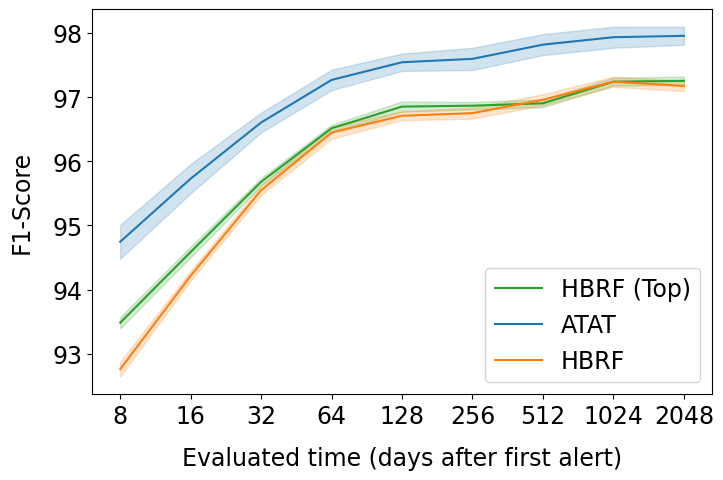

In [11]:
# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 5))

# Graficar los datos con barras de error
ax.plot(days, hbrf_top_f1, linestyle='-', label='HBRF (Top)', color='tab:green')
ax.plot(days, atat_f1, linestyle='-', label='ATAT', color='tab:blue')
ax.plot(days, hbrf_f1, linestyle='-', label='HBRF', color='tab:orange')

ax.fill_between(days, np.array(hbrf_top_f1) - np.array(hbrf_top_f1_err), np.array(hbrf_top_f1) + np.array(hbrf_top_f1_err), color='tab:green', alpha=0.2)
ax.fill_between(days, np.array(atat_f1) - np.array(atat_f1_err), np.array(atat_f1) + np.array(atat_f1_err), color='tab:blue', alpha=0.2)
ax.fill_between(days, np.array(hbrf_f1) - np.array(hbrf_f1_err), np.array(hbrf_f1) + np.array(hbrf_f1_err), color='tab:orange', alpha=0.2)


# Resaltar el máximo F1-score de todos los modelos
max_f1 = max(max(atat_f1), max(hbrf_f1), max(hbrf_top_f1)) 
max_idx = None
max_day = None

# Determinar a qué modelo y día pertenece el máximo F1-score
for idx, (a, h, c) in enumerate(zip(atat_f1, hbrf_f1, hbrf_top_f1)):
    if max_f1 in [a, h, c]:  # Verificar a qué curva pertenece
        max_idx = idx
        max_day = days[idx]
        break

# Dibujar línea y anotación del máximo F1-score
#ax.axhline(y=max_f1, linestyle='dashed', color='gray', alpha=0.6)
#ax.text(max_day, max_f1 + 0.01, f"Max F1: {max_f1:.3f}", ha="center", fontsize=10, color="gray", fontweight="bold")

# Configurar el eje X con escala logarítmica en base 2
list_time_to_eval = sorted(days)  # Asegurar que los valores estén ordenados
ax.set_xscale('log', base=2)
ax.set_xticks(list_time_to_eval)

# Configurar etiquetas, título y límites
fs = 17
#ax.set_title('F1-Score by Evaluation Time', fontsize=fs + 2, fontweight='bold', pad=15)
ax.set_xlabel('Evaluated time (days after first alert)', fontsize=fs, labelpad=13)
ax.set_ylabel('F1-Score', fontsize=fs, labelpad=13)
ax.tick_params(axis='y', labelsize=fs)
ax.set_xticklabels(list_time_to_eval, fontsize=fs)
#ax.set_ylim(51, 79)
ax.legend(fontsize=fs)

# Mostrar la gráfica
plt.savefig(f"{path_save_imgs}/eval_time_top_lvl_new_tax.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_confusion_matrix(matrices, order_classes, class_hierarchy=None, path_save=None, figsize=(13, 13), shrink=0.675):
    # Calculando la media y la desviación estándar
    median_matrix = np.median(matrices, axis=0)
    p5_matrix = np.abs(median_matrix - np.percentile(matrices, 5, axis=0))
    p95_matrix = np.abs(median_matrix - np.percentile(matrices, 95, axis=0)) 

    matrices_norm = np.array([m / m.sum(axis=1, keepdims=True) for m in matrices])
    matrices_norm = np.nan_to_num(matrices_norm)
    mean_matrices_norm = np.mean(matrices_norm, axis=0)
        
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=figsize) #, dpi=110)
    #norm = mcolors.Normalize(vmin=0, vmax=np.max(median_matrix))
    #median_matrix = 
    im = ax.imshow(np.around(mean_matrices_norm, decimals=2), interpolation='nearest', cmap=cmap, aspect=.9, vmax=1)#, #norm=norm)

    #divider = make_axes_locatable(ax)
    #cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, ax=ax, pad=0.05, aspect=20, shrink=shrink)
    cbar.ax.tick_params(labelsize=16)

    # color map
    new_color = cmap(1.0) 

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(median_matrix.shape[0]):
        for j in range(median_matrix.shape[1]):
            mean_val = int(median_matrix[i, j])
            p5_val = int(p5_matrix[i, j])
            p95_val = int(p95_matrix[i, j])

            text = f'{mean_val}'
            text_p95 = f'+{p95_val}' #if p95_val != 0 else ''  # P95 arriba
            text_p5 = f'−{p5_val}' #if p5_val != 0 else ''  # P5 abajo

            color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color

            ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=18.5)
            ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=14)
            ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=14)

            #if mean_matrices_norm[i, j] >= 0.005: #0.0005:
            #    text = f'{mean_val}'
            #    text_p95 = f'+{p95_val}' #if p95_val != 0 else ''  # P95 arriba
            #    text_p5 = f'−{p5_val}' #if p5_val != 0 else ''  # P5 abajo
#
            #    color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color
#
            #    ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=18.5)
            #    ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=14)
            #    ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=14)
            #else:
            #    text = f'{mean_val}'
            #    color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color
            #    ax.text(j, i, text, ha="center", va="center", color=color, fontsize=18.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    if class_hierarchy is not None:
        for class_list in class_hierarchy.values():
            indices = [order_classes.index(cls) for cls in class_list if cls in order_classes]
            if indices:
                min_idx, max_idx = min(indices), max(indices)
                rect = patches.Rectangle(
                    (min_idx - 0.5, min_idx - 0.5),  # Esquina superior izquierda
                    max_idx - min_idx + 1,  # Ancho
                    max_idx - min_idx + 1,  # Alto
                    linewidth=2, edgecolor="black", facecolor='none', clip_on=False
                )
                ax.add_patch(rect)

    ax.set_ylabel('True Label', fontsize=18.5)
    ax.set_xlabel('Predicted Label', fontsize=18.5)

    plt.setp(ax.get_xticklabels(), rotation=65, ha='center', va='top', rotation_mode="default")
    plt.tight_layout()

    if path_save is not None:
        plt.savefig(f"{path_save}", format="pdf", bbox_inches="tight")
    plt.show()

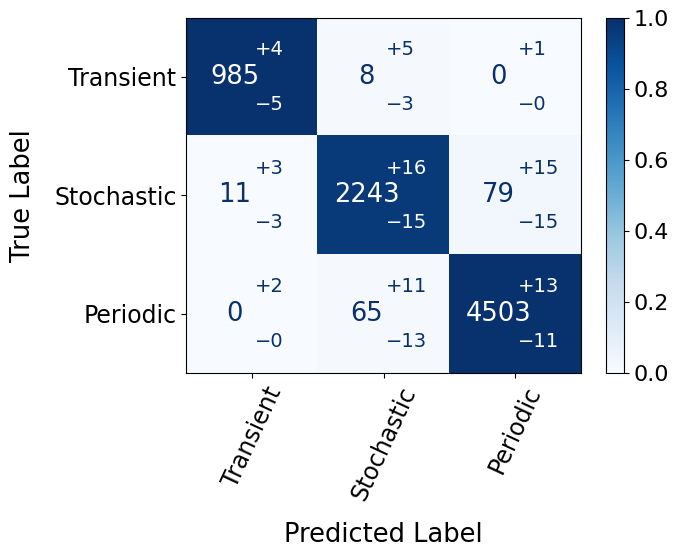

In [13]:
matrices = confusion_matrices['None']['ATAT']
path_save = f'{path_save_imgs}/cm_atat_top_lvl_new_tax.pdf'
get_confusion_matrix(matrices, order_high_taxonomy, class_hierarchy=None, path_save=path_save, figsize=(7,7), shrink=0.623)

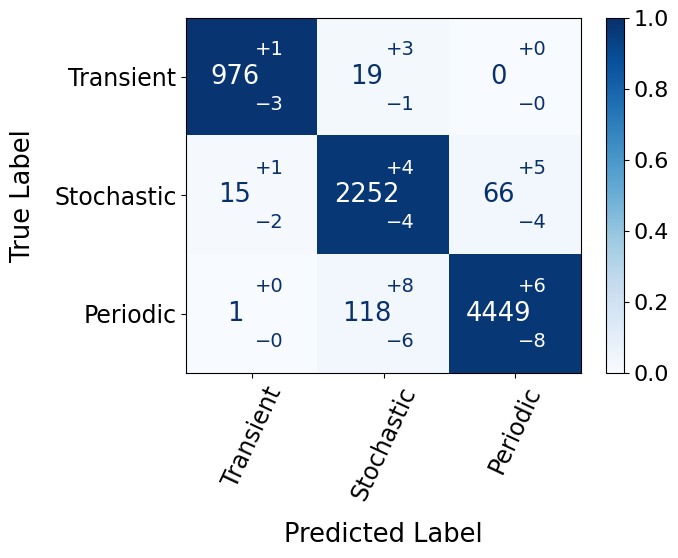

In [14]:
matrices = confusion_matrices['None']['HBRF']
path_save = f'{path_save_imgs}/cm_hbrf_top_lvl_new_tax.pdf'
get_confusion_matrix(matrices, order_high_taxonomy, class_hierarchy=None, path_save=path_save, figsize=(7,7), shrink=0.623)

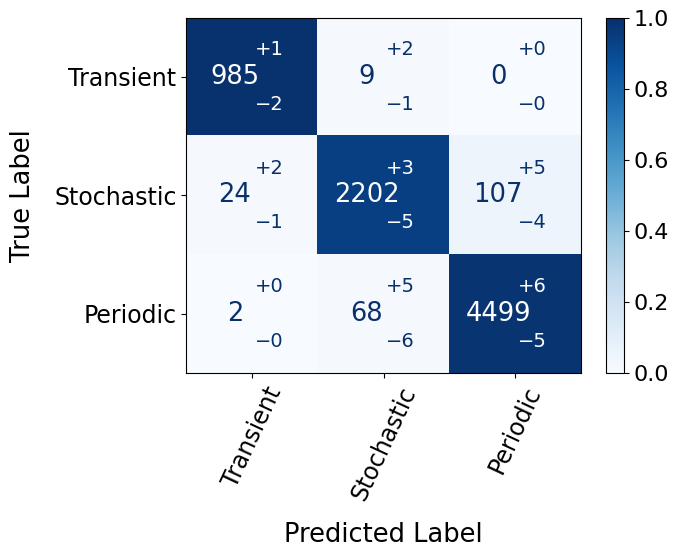

In [15]:
matrices = confusion_matrices['None']['HBRF (Top)']
path_save = f'{path_save_imgs}/cm_hbrf_top_lvl_new_tax.pdf'
get_confusion_matrix(matrices, order_high_taxonomy, class_hierarchy=None, path_save=path_save, figsize=(7,7), shrink=0.623)